# Рабочая тетрадь 7

Решены задания по теме нейронных сетей:

- реализованы две простые нейросети с фиксированными весами и порогами;
- показана замена сигмоиды на другие функции активации;
- обучен `MLPClassifier` на наборе Iris;
- обучен `MLPRegressor` на наборе Salary Data;
- проанализированы ключевые атрибуты полученных моделей.

In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.metrics import accuracy_score, confusion_matrix, mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
WORKBOOK_DIR = Path.cwd()
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True
print("Рабочая папка:", WORKBOOK_DIR)

Рабочая папка: /Users/akarmain/Zed/vanilla_code


## 1. Нейросети с фиксированными весами

В задании нужно реализовать классы по аналогии с `OurNeuralNetwork`.
Используем один и тот же нейрон: взвешенная сумма входов плюс порог
передаётся в сигмоиду. Сигмоида переводит любое вещественное число в
интервал `(0, 1)`, поэтому удобно читать результат как степень
активации нейрона.

In [2]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))


class FixedNeuron:
    def __init__(self, weights, bias, activation=sigmoid):
        self.weights = np.array(weights, dtype=float)
        self.bias = float(bias)
        self.activation = activation

    def feedforward(self, inputs):
        inputs = np.array(inputs, dtype=float)
        total = np.dot(self.weights, inputs) + self.bias
        return float(self.activation(total))


class ThreeInputNetwork:
    """3 входа -> 3 скрытых нейрона -> 1 выход."""

    def __init__(self):
        self.hidden = [FixedNeuron([0.5, 0.5, 0.5], 0) for _ in range(3)]
        self.output = FixedNeuron([0.5, 0.5, 0.5], 0)

    def feedforward(self, inputs):
        hidden_outputs = np.array([neuron.feedforward(inputs) for neuron in self.hidden])
        return self.output.feedforward(hidden_outputs), hidden_outputs


class TwoOutputNetwork:
    """2 входа -> 2 скрытых нейрона -> 2 выхода."""

    def __init__(self):
        self.hidden = [FixedNeuron([1, 0], 1) for _ in range(2)]
        self.outputs = [FixedNeuron([1, 0], 1), FixedNeuron([1, 0], 1)]

    def feedforward(self, inputs):
        hidden_outputs = np.array([neuron.feedforward(inputs) for neuron in self.hidden])
        output_values = np.array([neuron.feedforward(hidden_outputs) for neuron in self.outputs])
        return output_values, hidden_outputs


net_3_3_1 = ThreeInputNetwork()
result_3, hidden_3 = net_3_3_1.feedforward([2, 3, 4])

net_2_2_2 = TwoOutputNetwork()
result_2, hidden_2 = net_2_2_2.feedforward([2, 3])

fixed_network_results = pd.DataFrame(
    [
        {
            "Сеть": "3 входа -> 3 скрытых -> 1 выход",
            "Вход": "[2, 3, 4]",
            "Скрытый слой": np.round(hidden_3, 4).tolist(),
            "Выход": np.round(result_3, 4),
        },
        {
            "Сеть": "2 входа -> 2 скрытых -> 2 выхода",
            "Вход": "[2, 3]",
            "Скрытый слой": np.round(hidden_2, 4).tolist(),
            "Выход": np.round(result_2, 4).tolist(),
        },
    ]
)
display(fixed_network_results)

,Сеть,Вход,Скрытый слой,Выход
0,3 входа -> 3 скрытых -> 1 выход,"[2, 3, 4]","[0.989, 0.989, 0.989]",0.8151
1,2 входа -> 2 скрытых -> 2 выхода,"[2, 3]","[0.9526, 0.9526]","[0.8757, 0.8757]"


В первой сети каждый скрытый нейрон получает одинаковые веса, поэтому
все три скрытые активации совпадают. Во второй сети вес `[1, 0]`
означает, что нейрон фактически смотрит только на первый вход, а
второй вход не влияет на сумму.

## 2. Другие функции активации

Сигмоида не единственный вариант. Ниже одна и та же архитектура
запускается с `tanh`, `ReLU` и линейной функцией. Это показывает,
что архитектура сети может быть той же, но численный смысл выходов
меняется из-за функции активации.

,Функция активации,Выход сети
0,sigmoid,0.815104
1,tanh,0.905081
2,ReLU,6.750000
3,linear,6.750000


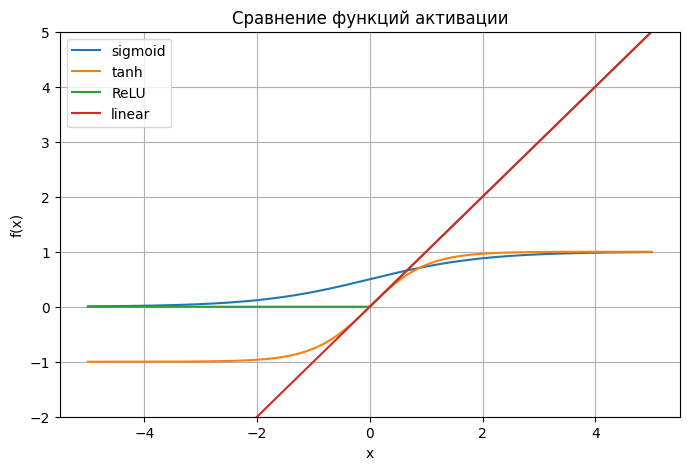

In [3]:
def relu(x):
    return np.maximum(0, x)


def linear(x):
    return x


def tanh(x):
    return np.tanh(x)


class ActivationNetwork:
    def __init__(self, activation):
        self.hidden = [FixedNeuron([0.5, 0.5, 0.5], 0, activation) for _ in range(3)]
        self.output = FixedNeuron([0.5, 0.5, 0.5], 0, activation)

    def feedforward(self, inputs):
        hidden_outputs = np.array([neuron.feedforward(inputs) for neuron in self.hidden])
        return self.output.feedforward(hidden_outputs)


activation_rows = []
for name, fn in {
    "sigmoid": sigmoid,
    "tanh": tanh,
    "ReLU": relu,
    "linear": linear,
}.items():
    network = ActivationNetwork(fn)
    activation_rows.append({"Функция активации": name, "Выход сети": network.feedforward([2, 3, 4])})

activation_df = pd.DataFrame(activation_rows)
activation_df["Выход сети"] = activation_df["Выход сети"].round(6)
display(activation_df)

x_axis = np.linspace(-5, 5, 300)
plt.figure(figsize=(8, 5))
plt.plot(x_axis, sigmoid(x_axis), label="sigmoid")
plt.plot(x_axis, tanh(x_axis), label="tanh")
plt.plot(x_axis, relu(x_axis), label="ReLU")
plt.plot(x_axis, linear(x_axis), label="linear")
plt.ylim(-2, 5)
plt.title("Сравнение функций активации")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.show()

`ReLU` зануляет отрицательные значения и оставляет положительные без
изменения. `tanh` похожа на сигмоиду, но возвращает значения от `-1`
до `1`. Линейная функция полезна для объяснения вычислений, но без
нелинейности несколько слоёв сводятся к одной линейной модели.

## 3. MLPClassifier для Iris

Для классификации берём набор Iris. Цель модели — по четырём
измерениям цветка определить вид ириса. Признаки стандартизируются:
для MLP это важно, потому что градиентный метод чувствителен к
масштабу входов.

In [4]:
iris_url = "https://gist.githubusercontent.com/netj/8836201/raw/6f9306ad21398ea43cba4f7d537619d0e07d5ae3/iris.csv"
try:
    iris_df = pd.read_csv(iris_url)
    iris_source = "URL из задания"
    feature_columns = ["sepal.length", "sepal.width", "petal.length", "petal.width"]
    target_column = "variety"
    X_cls = iris_df[feature_columns].to_numpy()
    y_labels = iris_df[target_column].to_numpy()
    encoder = LabelEncoder()
    y_cls = encoder.fit_transform(y_labels)
    target_names = encoder.classes_
except Exception:
    iris = load_iris(as_frame=True)
    iris_source = "sklearn.datasets.load_iris"
    iris_df = iris.frame
    X_cls = iris.data.to_numpy()
    y_cls = iris.target.to_numpy()
    target_names = iris.target_names

X_train, X_test, y_train, y_test = train_test_split(
    X_cls, y_cls, test_size=0.2, random_state=RANDOM_STATE, stratify=y_cls
)

classifier = make_pipeline(
    StandardScaler(),
    MLPClassifier(hidden_layer_sizes=(12, 8), max_iter=1500, random_state=RANDOM_STATE)
)
classifier.fit(X_train, y_train)
y_pred = classifier.predict(X_test)
mlp_classifier = classifier.named_steps["mlpclassifier"]

cls_metrics = pd.DataFrame(
    {
        "Метрика": ["Источник данных", "Размер train", "Размер test", "Accuracy", "Loss", "Итерации"],
        "Значение": [
            iris_source,
            len(X_train),
            len(X_test),
            round(accuracy_score(y_test, y_pred), 4),
            round(mlp_classifier.loss_, 6),
            mlp_classifier.n_iter_,
        ],
    }
)
display(cls_metrics)

,Метрика,Значение
0,Источник данных,URL из задания
1,Размер train,120
2,Размер test,30
3,Accuracy,0.9667
4,Loss,0.057154
5,Итерации,665


,Setosa,Versicolor,Virginica
Setosa,10,0,0
Versicolor,0,9,1
Virginica,0,0,10


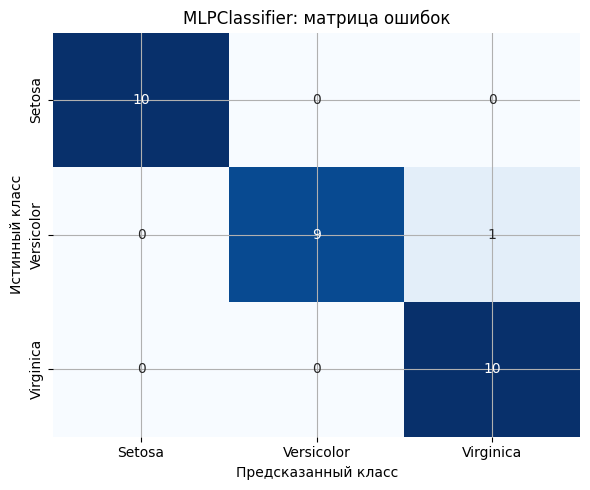

,Атрибут,Значение,Смысл
0,loss_,0.057154,финальное значение функции потерь
1,n_iter_,665,сколько итераций обучения выполнено
2,out_activation_,softmax,активация выходного слоя
3,coefs_,"[(4, 12), (12, 8), (8, 3)]",матрицы весов между слоями
4,intercepts_,"[(12,), (8,), (3,)]",векторы смещений слоёв


In [5]:
cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(cm, index=target_names, columns=target_names)
display(cm_df)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("MLPClassifier: матрица ошибок")
plt.xlabel("Предсказанный класс")
plt.ylabel("Истинный класс")
plt.tight_layout()
plt.show()

classifier_attributes = pd.DataFrame(
    [
        {"Атрибут": "loss_", "Значение": round(mlp_classifier.loss_, 6), "Смысл": "финальное значение функции потерь"},
        {"Атрибут": "n_iter_", "Значение": mlp_classifier.n_iter_, "Смысл": "сколько итераций обучения выполнено"},
        {"Атрибут": "out_activation_", "Значение": mlp_classifier.out_activation_, "Смысл": "активация выходного слоя"},
        {"Атрибут": "coefs_", "Значение": str([w.shape for w in mlp_classifier.coefs_]), "Смысл": "матрицы весов между слоями"},
        {"Атрибут": "intercepts_", "Значение": str([b.shape for b in mlp_classifier.intercepts_]), "Смысл": "векторы смещений слоёв"},
    ]
)
display(classifier_attributes)

Матрица ошибок показывает, какие виды ирисов модель путает между собой.
Атрибуты `coefs_` и `intercepts_` подтверждают архитектуру сети:
количество матриц весов равно числу переходов между слоями.

## 4. MLPRegressor для Salary Data

Для регрессии используем зависимость зарплаты от стажа. Цель —
предсказать `Salary` по признаку `YearsExperience`. Для устойчивого
обучения снова применяем стандартизацию.

In [6]:
salary_path = WORKBOOK_DIR.parent / "Workbook_4" / "Salary_Data.csv"
salary_url = "https://raw.githubusercontent.com/AnnaShestova/salary-years-simple-linear-regression/master/Salary_Data.csv"
if salary_path.exists():
    salary_df = pd.read_csv(salary_path)
    salary_source = str(salary_path.relative_to(WORKBOOK_DIR.parent))
else:
    salary_df = pd.read_csv(salary_url)
    salary_source = "URL из задания"

X_reg = salary_df[["YearsExperience"]].to_numpy()
y_reg = salary_df["Salary"].to_numpy()
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.25, random_state=RANDOM_STATE
)

y_mean = y_train_r.mean()
y_std = y_train_r.std()
y_train_scaled = (y_train_r - y_mean) / y_std

regressor = make_pipeline(
    StandardScaler(),
    MLPRegressor(hidden_layer_sizes=(16, 8), activation="relu", max_iter=3000, random_state=RANDOM_STATE)
)
regressor.fit(X_train_r, y_train_scaled)
y_pred_r = regressor.predict(X_test_r) * y_std + y_mean
mlp_regressor = regressor.named_steps["mlpregressor"]
rmse_value = np.sqrt(mean_squared_error(y_test_r, y_pred_r))

reg_metrics = pd.DataFrame(
    {
        "Метрика": ["Источник данных", "MAE", "RMSE", "R2", "Loss", "Итерации"],
        "Значение": [
            salary_source,
            round(mean_absolute_error(y_test_r, y_pred_r), 2),
            round(rmse_value, 2),
            round(r2_score(y_test_r, y_pred_r), 4),
            round(mlp_regressor.loss_, 2),
            mlp_regressor.n_iter_,
        ],
    }
)
display(reg_metrics)

comparison = pd.DataFrame(
    {
        "YearsExperience": X_test_r.ravel(),
        "Salary true": y_test_r,
        "Salary predicted": np.round(y_pred_r, 2),
        "Ошибка": np.round(y_test_r - y_pred_r, 2),
    }
).sort_values("YearsExperience")
display(comparison)

,Метрика,Значение
0,Источник данных,URL из задания
1,MAE,5028.79
2,RMSE,6120.09
3,R2,0.937
4,Loss,0.02
5,Итерации,205


,YearsExperience,Salary true,Salary predicted,Ошибка
4,3.2,64445.0,54841.48,9603.52
5,3.7,57189.0,58344.07,-1155.07
1,4.9,67938.0,71301.00,-3363.00
3,5.3,83088.0,76392.28,6695.72
2,8.2,113812.0,103375.74,10436.26
7,8.7,109431.0,106544.87,2886.13
0,9.6,112635.0,112249.31,385.69
6,10.3,122391.0,116686.10,5704.90


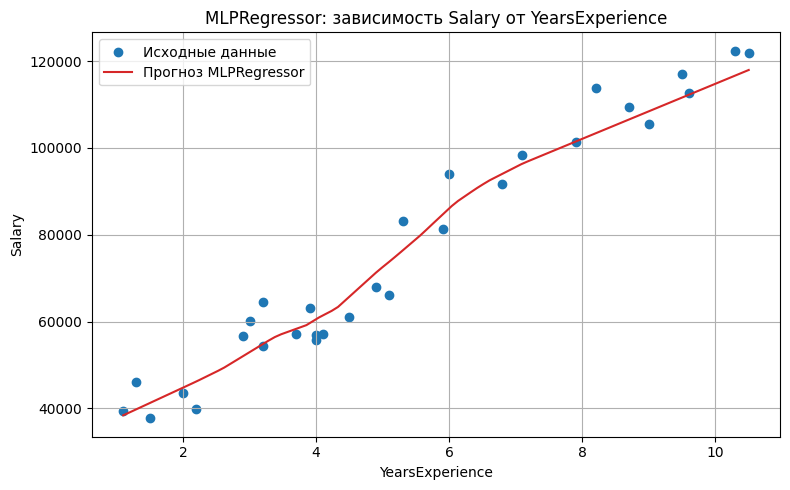

,Атрибут,Значение,Смысл
0,loss_,0.02,финальная ошибка обучения
1,n_iter_,205,число итераций оптимизации
2,out_activation_,identity,для регрессии обычно identity
3,coefs_,"[(1, 16), (16, 8), (8, 1)]",формы матриц весов
4,intercepts_,"[(16,), (8,), (1,)]",формы векторов смещений


In [7]:
x_line = np.linspace(X_reg.min(), X_reg.max(), 100).reshape(-1, 1)
y_line = regressor.predict(x_line) * y_std + y_mean

plt.figure(figsize=(8, 5))
plt.scatter(X_reg, y_reg, label="Исходные данные", color="tab:blue")
plt.plot(x_line, y_line, label="Прогноз MLPRegressor", color="tab:red")
plt.title("MLPRegressor: зависимость Salary от YearsExperience")
plt.xlabel("YearsExperience")
plt.ylabel("Salary")
plt.legend()
plt.tight_layout()
plt.show()

regressor_attributes = pd.DataFrame(
    [
        {"Атрибут": "loss_", "Значение": round(mlp_regressor.loss_, 2), "Смысл": "финальная ошибка обучения"},
        {"Атрибут": "n_iter_", "Значение": mlp_regressor.n_iter_, "Смысл": "число итераций оптимизации"},
        {"Атрибут": "out_activation_", "Значение": mlp_regressor.out_activation_, "Смысл": "для регрессии обычно identity"},
        {"Атрибут": "coefs_", "Значение": str([w.shape for w in mlp_regressor.coefs_]), "Смысл": "формы матриц весов"},
        {"Атрибут": "intercepts_", "Значение": str([b.shape for b in mlp_regressor.intercepts_]), "Смысл": "формы векторов смещений"},
    ]
)
display(regressor_attributes)

Вывод: MLP может решать и классификацию, и регрессию, но для малых
табличных данных результат сильно зависит от масштаба признаков,
архитектуры сети и числа итераций. Поэтому в решении используется
`StandardScaler`, фиксированный `random_state` и анализ атрибутов
обученной модели.